## Libraries

In [1]:
!pip install -q \
  datasets \
  transformers \
  peft \
  huggingface_hub \
  ipywidgets

!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 673.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys
import time
import torch
import random
import ipywidgets
import pandas as pd
import json
import plotly.express as px
from datetime import datetime
from torch.utils.data import Dataset
from datasets import load_dataset, concatenate_datasets
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from itertools import islice
import matplotlib.pyplot as plt
from IPython.display import clear_output, display, update_display, DisplayHandle
from huggingface_hub import login, HfFolder, HfApi, hf_hub_download, delete_repo, list_repo_files, snapshot_download
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig, TrainerCallback, DataCollatorWithPadding
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:32" # Allows to split memory into pieces when allocating (normally the GPU VRAM needs a contiguous block of memory). Caps memory block size to maximum of 32 MB

## Load model & dataset

##### Login to huggingface

In [3]:
login()

#### Load base model

The GPU VRAM is not sufficient for training the model. We use LoRA to make it more efficient

In [4]:
# Use only for loading new tinyllama model

"""

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# Load model with 8-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,               # 8-bit quantization
    device_map="auto"                # Automatically place layers on GPU/CPU
)

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Apply LoRA to the quantized model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

"""

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


#### Load fine-tuned model with LoRA adapters

In [ ]:
# Load base model
base = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,        # 8-bit quantization
    device_map="auto"
)

# Load your previously trained LoRA adapter (set as trainable)
model = PeftModel.from_pretrained(
    base,
    "eduhuemar001/tinyllama-german-sentiment",
    is_trainable=True         # Required for continued training
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

model.print_trainable_parameters()  # Only LoRA layers should be trainable
print(model.base_model_prefix)
print(model)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
model
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

#### Load dataset

In [5]:
# --- Constants ---
HF_DATASET_REPO_ID = "eduhuemar001/tinyllama-german-dataset-sentiment-temp"
DATASET_FILE = "current_dataset.json"
LOCAL_DATASET_PATH = f"/content/{DATASET_FILE}"
REMOTE_DATASET_PATH = f"{DATASET_FILE}"

HF_DATASET_REPO_GERMEVAL = "eduhuemar001/sentiment-GermEval2017"
HF_DATASET_REPO_SB10K = "eduhuemar001/sentiment-SB10k"
HF_DATASET_REPO_HOLIDAYCHECK = "eduhuemar001/sentiment-holidaycheck-balanced"

api = HfApi()

# --- Check if dataset exists ---
try:
    files = list_repo_files(HF_DATASET_REPO_ID, repo_type="dataset")
    dataset_exists = REMOTE_DATASET_PATH in files
except Exception as e:
    print(f"Repo does not exist or could not be listed: {e}")
    files = []
    dataset_exists = False

if dataset_exists:
    print("Loading existing dataset from Hugging Face Hub...")

    dataset_path = hf_hub_download(
        repo_id=HF_DATASET_REPO_ID,
        filename=REMOTE_DATASET_PATH,
        repo_type="dataset",
        local_dir="/content",
        local_dir_use_symlinks=False
    )

    with open(dataset_path, "r", encoding="utf-8") as f:
        dataset_save = json.load(f)

    dataset = dataset_save["corpus"]

else:
    print("No existing dataset found. Loading sentiment datasets from Hugging Face Hub...")

    # Load GermEval and SB10k
    ds_germeval = load_dataset(HF_DATASET_REPO_GERMEVAL, split="train")
    ds_sb10k = load_dataset(HF_DATASET_REPO_SB10K, split="train")

    # Load HolidayCheck fully (~800MB)
    ds_holidaycheck_full = load_dataset(HF_DATASET_REPO_HOLIDAYCHECK, split="train")

    # Sample small part of HolidayCheck dataset
    hc_sample_size = 65536 if len(ds_holidaycheck_full) > 65536 else len(ds_holidaycheck_full)
    ds_holidaycheck = ds_holidaycheck_full.shuffle(seed=random.randint(0, 1_000_000)).select(range(hc_sample_size))

    # Combine and shuffle all datasets
    combined_ds = concatenate_datasets([ds_germeval, ds_sb10k, ds_holidaycheck])
    combined_ds = combined_ds.shuffle(seed=random.randint(0, 1_000_000))

    # Format as instruction prompts
    dataset = [
        {
            "text": (
                f"### Instruction:\nKlassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'negativ'.\n\n"
                f"### Bewertung:\n{row['review_text']}\n\n### Antwort:\n{row['sentiment']}"
            ),
            "sentiment": row["sentiment"]
        }
        for row in combined_ds
    ]

    dataset_save = {
        "corpus": dataset
    }

    # Save locally
    with open(LOCAL_DATASET_PATH, "w", encoding="utf-8") as f:
        json.dump(dataset_save, f, ensure_ascii=False, indent=2)

    # Upload to Hugging Face Hub
    api.create_repo(
        repo_id=HF_DATASET_REPO_ID,
        repo_type="dataset",
        exist_ok=True,
        token=True
    )

    api.upload_file(
        path_or_fileobj=LOCAL_DATASET_PATH,
        path_in_repo=REMOTE_DATASET_PATH,
        repo_id=HF_DATASET_REPO_ID,
        repo_type="dataset",
        commit_message="Saving current sentiment-based dataset snapshot with capped HolidayCheck data"
    )

    print("Sentiment dataset (capped) uploaded to Hugging Face.")

Repo does not exist or could not be listed: 404 Client Error. (Request ID: Root=1-681f17b2-016e74084656dc6018119eea;e1ba050b-f181-4f00-8d67-dccf6ac97b47)

Repository Not Found for url: https://huggingface.co/api/datasets/eduhuemar001/tinyllama-german-dataset-sentiment-temp/tree/main?recursive=True&expand=False.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
No existing dataset found. Loading sentiment datasets from Hugging Face Hub...


germeval2017_cleaned.csv:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

sb10k_cleaned.csv:   0%|          | 0.00/552k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

holidaycheck_reviews_binary_balanced.csv:   0%|          | 0.00/803M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

current_dataset.json:   0%|          | 0.00/61.4M [00:00<?, ?B/s]

Sentiment dataset (capped) uploaded to Hugging Face.


## Preprocessing

#### Tokenize data

The full sentiment prompt and label are kept together. Avoid information loss from chunking (one "chunk" has variable size).

In [6]:
print(dataset[:10])

[{'text': '### Instruction:\nKlassifiziere die Stimmung der folgenden Bewertung als \'positiv\', \'neutral\' oder \'negativ\'.\n\n### Bewertung:\n"Die S- Bahn ist ja angepinselt wie ein Zebra!" "Ist wohl ein Streifzug..."\n\n### Antwort:\nneutral', 'sentiment': 'neutral'}, {'text': "### Instruction:\nKlassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'negativ'.\n\n### Bewertung:\nDie Zimmer sind landestypisch eingerichtet. Es war groß, hell und immer sauber, mit Blick zum Garten und zum Meer. Jedes Zimmer hat eine Terasse oder einen Balkon. Der Kühlschrank wird täglich mit neuen Wasserflaschen aufgefüllt. Die Klimaanlage kann man gut regulieren und auch ein Fön ist in jedem Zimmer vorhanden. Dieses Mal haben wir uns keine eigenen Handtücher mitgebracht, da die Handtücher im Zimmer immer sauber und ordentlich sind.\n\n### Antwort:\npositive", 'sentiment': 'positive'}, {'text': "### Instruction:\nKlassifiziere die Stimmung der folgenden Bewertung als 'positi

In [9]:
train_dataset = None

class SentimentDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.data = []

        for item in dataset:
            label_text = item["sentiment"].strip()
            full_text = item["text"]

            # Remove the label from the full prompt
            if "### Antwort:" not in full_text:
                continue  # skip malformed data

            prompt_text = full_text.rsplit("### Antwort:", 1)[0] + "### Antwort:\n"

            # Tokenize prompt and label separately
            prompt_tokens = self.tokenizer(prompt_text, add_special_tokens=False)["input_ids"]
            label_tokens = self.tokenizer(label_text, add_special_tokens=False)["input_ids"]

            # Reserve space for the full label
            max_prompt_len = self.max_length - len(label_tokens)
            if max_prompt_len <= 0:
                continue  # skip if label is too long

            # Truncate prompt if necessary
            prompt_tokens = prompt_tokens[:max_prompt_len]

            # Final sequence
            input_ids = prompt_tokens + label_tokens
            labels = [-100] * len(prompt_tokens) + label_tokens

            # Padding
            pad_len = self.max_length - len(input_ids)
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            labels += [-100] * pad_len

            # Safety check
            if len(input_ids) != self.max_length or len(labels) != self.max_length:
                continue

            self.data.append({
                "input_ids": torch.tensor(input_ids, dtype=torch.long),
                "labels": torch.tensor(labels, dtype=torch.long)
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = SentimentDataset(dataset, tokenizer, max_length=128)

In [10]:
for i in range(3):
    print(f"\n--- Sample {i} ---")
    sample = train_dataset[i]
    ids = sample["input_ids"]
    lbls = sample["labels"]
    print("Decoded input:", tokenizer.decode(ids, skip_special_tokens=True))
    print("Decoded label:", tokenizer.decode([id for id, l in zip(ids, lbls) if l != -100]))


--- Sample 0 ---
Decoded input: ### Instruction:
Klassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'negativ'.

### Bewertung:
### Instruction:
Klassifiziere die Stimmung der folgenden Bewertung als '', '' oder ''.

### Bewertung:
"Die S- Bahn ist ja angepinselt wie ein Zebra!" "Ist wohl ein Streifzug..."

### Antwort:

### Antwort:
 neutral
Decoded label: neutral

--- Sample 1 ---
Decoded input: ### Instruction:
Klassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'negativ'.

### Bewertung:
### Instruction:
Klassifiziere die Stimmung der folgenden Bewertung als '', '' oder ''.

### Bewertung:
Die Zimmer sind landestypisch eingerichtet. Es war groß, hell und immer sauber, mit Blick zum Garten und zum Meer. Jedes Zimmer hat eine Terasse oder einen Balkon. Der Kü positive
Decoded label: positive

--- Sample 2 ---
Decoded input: ### Instruction:
Klassifiziere die Stimmung der folgenden Bewertung als 'positiv', 'neutral' oder 'nega

## Logging & Plotting

#### Load previous logs

In [ ]:
HF_LOG_REPO_ID = "eduhuemar001/tinyllama-german-sentiment"
LOG_SUBDIR = "logs"

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
logfile_name = f"loss_log_{timestamp}.csv"
remote_log_path = f"{LOG_SUBDIR}/{logfile_name}"
local_log_path = f"/content/{logfile_name}"

api = HfApi()
total_logged_steps = 0
all_logs = []

for file in list_repo_files(HF_LOG_REPO_ID, repo_type="model"):
    if file.startswith(LOG_SUBDIR) and file.endswith(".csv"):
        try:
            local_path = hf_hub_download(
                repo_id=HF_LOG_REPO_ID,
                repo_type="model",
                filename=file,
                local_dir="/content",
                local_dir_use_symlinks=False
            )
            df = pd.read_csv(local_path)
            all_logs.append(df)
            if not df.empty:
                step_max = df["global_step"].max()
                if step_max > total_logged_steps:
                    total_logged_steps = step_max
        except:
            print(f"Failed to load: {file}")

In [ ]:
print(total_logged_steps)

0


#### Create logging callback

In [ ]:
class LossLoggingCallback(TrainerCallback):
    def __init__(self, local_path, remote_path, repo_id, step_offset=0, flush_every_n_steps=50):
        self.local_path = local_path
        self.remote_path = remote_path
        self.repo_id = repo_id
        self.step_offset = step_offset
        self.flush_every_n_steps = flush_every_n_steps
        self.losses = []
        self.initial_global_step = None

    def on_train_begin(self, args, state, control, **kwargs):
        # Initialize at the very start of training
        if self.initial_global_step is None:
            self.initial_global_step = state.global_step
            print(f"[Init] Training starts at global_step: {self.initial_global_step}")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step
            adjusted_step = self.step_offset + (step - self.initial_global_step)
            loss = logs["loss"]
            self.losses.append((adjusted_step, loss))

            if len(self.losses) % self.flush_every_n_steps == 0:
                self._flush_log(adjusted_step)

    def on_save(self, args, state, control, **kwargs):
        if self.losses:
            last_logged_step = self.step_offset + (state.global_step - self.initial_global_step)
            self._flush_log(last_logged_step)

    def on_train_end(self, args, state, control, **kwargs):
        if self.losses:
            final_step = self.step_offset + (state.global_step - self.initial_global_step)
            self._flush_log(final_step)

    def _flush_log(self, current_step):
        try:
            df = pd.DataFrame(self.losses, columns=["global_step", "training_loss"])
            df.to_csv(self.local_path, index=False)

            api = HfApi()
            api.upload_file(
                path_or_fileobj=self.local_path,
                path_in_repo=self.remote_path,
                repo_id=self.repo_id,
                repo_type="model",
                commit_message=f"Auto-flushed loss log at step {current_step}"
            )
            print(f"Loss log flushed to Hugging Face at step {current_step}")
        except Exception as e:
            print(f"Failed to upload loss log at step {current_step}: {e}")

#### Create real-time plotting callback

In [ ]:
class LiveLossPlotCallback(TrainerCallback):
    def __init__(self, base_logs=None, step_offset=0, gap_threshold=500):
        self.df_history = pd.concat(base_logs, ignore_index=True) if base_logs else pd.DataFrame(columns=["global_step", "training_loss"])
        self.step_offset = step_offset
        self.gap_threshold = gap_threshold
        self.new_data = []
        self.display_handle = None
        self.initialized = False
        self.initial_global_step = None  # Will be set in on_train_begin

    def on_train_begin(self, args, state, control, **kwargs):
        # Ensure to capture the actual starting global step
        if self.initial_global_step is None:
            self.initial_global_step = state.global_step
            print(f"[LivePlot Init] Training starts at global_step: {self.initial_global_step}")

    def _render_plots(self):
        if not self.new_data:
            return

        # --- Corrected Cumulative Plot Data ---
        adjusted_cumulative_data = [
            ((s - self.initial_global_step) + self.step_offset, l) for s, l in self.new_data
        ]

        df_all = pd.concat([
            self.df_history,
            pd.DataFrame(adjusted_cumulative_data, columns=["global_step", "training_loss"])
        ], ignore_index=True)

        df_all.sort_values("global_step", inplace=True)

        # Insert NaNs for step gaps
        step_diff = df_all["global_step"].diff()
        gap_indices = step_diff[step_diff > self.gap_threshold].index
        for idx in gap_indices[::-1]:
            df_all = pd.concat([
                df_all.iloc[:idx],
                pd.DataFrame({"global_step": [None], "training_loss": [None]}),
                df_all.iloc[idx:]
            ], ignore_index=True)

        # --- Current session: normalize steps to start from 0 ---
        df_current = pd.DataFrame(self.new_data, columns=["step", "training_loss"])
        df_current["step"] = df_current["step"] - self.initial_global_step  # Correct relative step

        # --- Plot both graphs ---
        fig, (ax_all, ax_current) = plt.subplots(2, 1, figsize=(10, 8))

        # Cumulative Plot
        ax_all.plot(df_all["global_step"], df_all["training_loss"], marker=',', linestyle='-', label="Cumulative Loss")
        ax_all.set_xlabel("Global Step")
        ax_all.set_ylabel("Loss")
        ax_all.set_title("Live Training Loss (All Trainings)")
        ax_all.grid(True)

        # Current Run Plot
        ax_current.plot(df_current["step"], df_current["training_loss"], marker=',', linestyle='-', color='orange', label="Current Session")
        ax_current.set_xlabel("Step")
        ax_current.set_ylabel("Loss")
        ax_current.set_title("Live Training Loss (Current Training)")
        ax_current.grid(True)

        plt.tight_layout()

        if not self.initialized:
            self.display_handle = display(fig, display_id=True)
            self.initialized = True
        else:
            update_display(fig, display_id=self.display_handle.display_id)

        plt.close(fig)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            step = state.global_step
            loss = logs["loss"]

            self.new_data.append((step, loss))
            self._render_plots()

## Set training arguments

In [ ]:
HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints-sentiment"
save_steps = 100

training_args = TrainingArguments(
    output_dir="./results",             # local temp folder
    save_strategy="steps",              # save every N steps
    save_steps=save_steps,              # step count before saving
    save_total_limit=1,                 # keep only the latest checkpoint
    push_to_hub=True,
    hub_model_id=HF_REPO_ID,
    hub_strategy="checkpoint",          # push checkpoints to HF
    logging_dir="./logs",
    logging_steps=50,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    report_to="none"
)

live_plot_cb = LiveLossPlotCallback(
    base_logs=all_logs,
    step_offset=total_logged_steps,
    gap_threshold=save_steps
)

loss_callback = LossLoggingCallback(
    local_path=local_log_path,
    remote_path=remote_log_path,
    repo_id=HF_LOG_REPO_ID,
    step_offset=total_logged_steps,
    flush_every_n_steps=50
)


data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    callbacks=[loss_callback, live_plot_cb]
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


## Start training loop

#### Start initial training or resume training if checkpoint exists. The checkpoints are saved to huggingface. Save model to huggingface after finished training.

No checkpoint found.
Starting fresh training...
[Init] Training starts at global_step: 0
[LivePlot Init] Training starts at global_step: 0


Step,Training Loss
50,5.878300
100,1.373600
150,1.067200
200,0.721700
250,0.541400
300,1.615200
350,0.937000
400,0.961100
450,1.216500
500,0.936900


<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


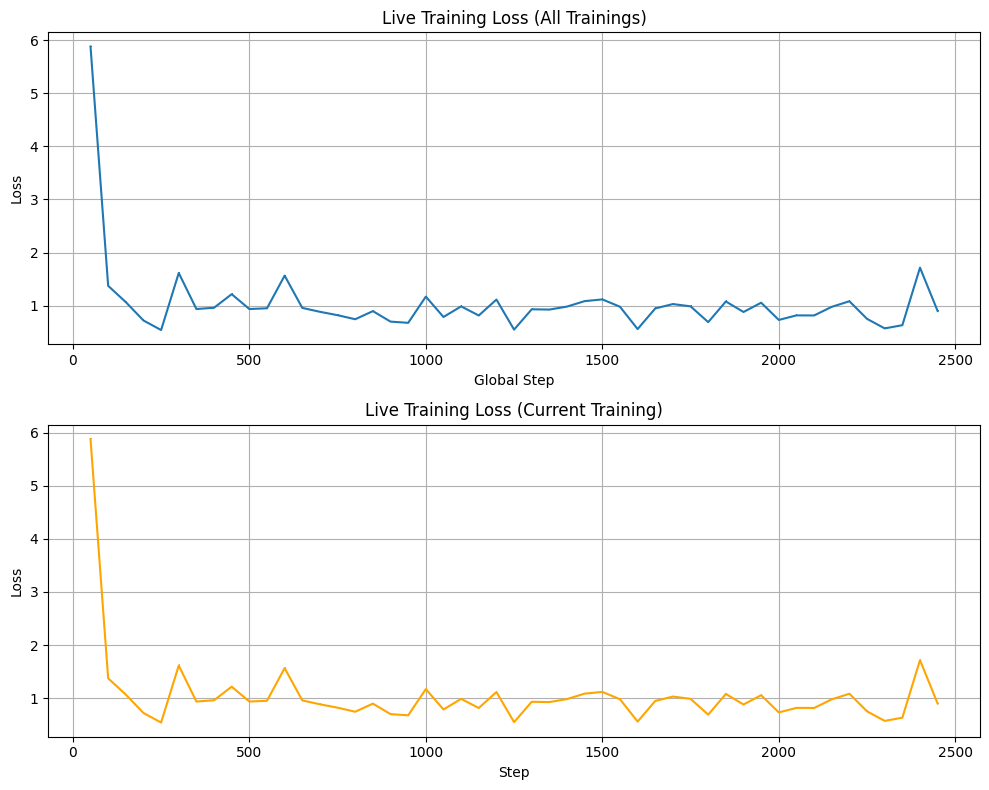

<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


Loss log flushed to Hugging Face at step 100


<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([
<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


Loss log flushed to Hugging Face at step 200


<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([
<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


...

Loss log flushed to Hugging Face at step 2300


<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([
<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


Loss log flushed to Hugging Face at step 2400


<ipython-input-11-ae2c0e52a09b>:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([


KeyboardInterrupt: 

In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints-sentiment"
resume_checkpoint = None

# Check if checkpoint exists
api = HfApi()
try:
    files = list_repo_files(repo_id=HF_REPO_ID, repo_type="model")
    checkpoints = [f for f in files if "checkpoint" in f]
    if checkpoints:
        print("Found checkpoint on Hugging Face Hub.")
        resume_checkpoint = HF_REPO_ID
    else:
        print("No checkpoint found.")
except Exception as e:
    print("Error checking checkpoint repo:", e)

# Train
start_time = time.time()
if resume_checkpoint:
    print(f"Resuming from HF checkpoint: {resume_checkpoint}")
    local_path = snapshot_download(
      repo_id="eduhuemar001/tinyllama-german-checkpoints",
      repo_type="model",
      local_dir="/content/hf-checkpoints",
    )

    # Resume from actual subfolder path
    resume_checkpoint = os.path.join(local_path, "last-checkpoint")
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    print("Starting fresh training...")
    trainer.train()
end_time = time.time()
print(f"Training took {end_time - start_time:.2f} seconds")

# Save LoRA adapter (not full model)
model.save_pretrained("tinyllama-german-lora")
tokenizer.save_pretrained("tinyllama-german-lora")

# Upload adapter only
api.upload_folder(
    folder_path="tinyllama-german-lora",
    repo_id="eduhuemar001/tinyllama-german-sentiment",
    repo_type="model",
    commit_message="Uploading LoRA adapter after training."
)

# Delete HF checkpoint after successful training
try:
    print(f"Deleting checkpoint repo: {HF_REPO_ID}")
    delete_repo(repo_id=HF_REPO_ID, repo_type="model")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

# Delete dataset snapshot after successful training
try:
    print(f"Deleting checkpoint repo: eduhuemar001/tinyllama-german-dataset")
    delete_repo(repo_id="eduhuemar001/tinyllama-german-dataset-sentiment-temp", repo_type="dataset")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

## Appendix

#### Memory usage

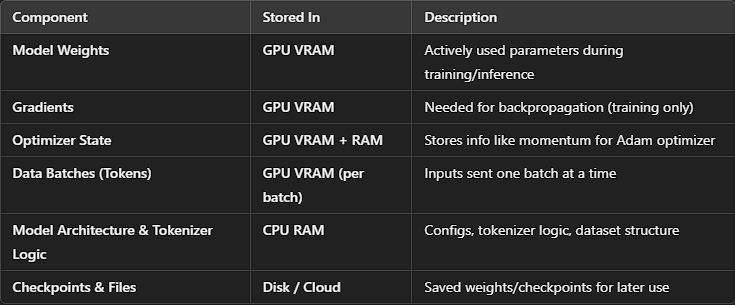